In [12]:
from google.cloud import bigquery
import pandas as pd
from decimal import Decimal
import traceback
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3

from pandas.tseries.offsets import CustomBusinessDay

import glob
import os

import gc 

# Get the Historical Sals Order Data from BigQuery

In [ ]:
PROJECT_ID = "clean-pilot-456915-t0"
client = bigquery.Client(project= PROJECT_ID)
df = client.query("""  
SELECT 
    t.id,
    t.tranid,
    t.trandate,
    t.status,
    t.type,
    tl.item,
    i.fullname,
    i.class,
    i.manufacturer,          
    c.category,             
    tl.quantity,
    tl.quantitybackordered,
    tl.netamount,
    tl.rate,
    tl.costestimate,
    tl.inventorylocation,    
    tl.custcolfree_goods_checkbox  
FROM `clean-pilot-456915-t0.NetSuite.transaction` t
JOIN `clean-pilot-456915-t0.NetSuite.transactionline` tl ON t.id = tl.transaction
JOIN `clean-pilot-456915-t0.NetSuite.customer` c ON t.entity = c.id
LEFT JOIN `clean-pilot-456915-t0.NetSuite.item` i ON tl.item = i.id
WHERE t.trandate <= DATE_SUB(CURRENT_DATE(), INTERVAL 1 DAY)
  AND t.type IN ('SalesOrd')   
  AND t.entity NOT IN (604610, 615265)
  AND c.category != 6                      -- exclude wholesale
  AND tl.mainline = FALSE
  AND tl.taxline = FALSE
  --AND tl.inventorylocation = 1
  AND tl.itemtype = 'InvtPart'
  AND i.manufacturer != 'D2'
ORDER BY t.trandate DESC
""").to_dataframe()

In [ ]:
# With all sales history until yesterday
so = df.groupby(by = ["tranid", "item"], as_index=False).agg(
    quantity = ("quantity", "sum"), 
    netamount = ("netamount", "sum"),
    costestimate = ("costestimate", "sum"), 
    status = ("status","first"),
    trandate = ("trandate", "first"), 
    type = ("type", "first")
)
# Adjust the quantitative columns
adj_list = ["quantity", "netamount","costestimate"]
for col in adj_list:
    so[col] = so[col]*-1

# Include 'Paid In Full' only - B
valid_so = so[(so["status"] != "H") & (so["status"] != "C")]

# daily demand per item 
daily_demand = valid_so.groupby(by = ["item", "trandate"], as_index = False).agg(daily_demand = ("quantity", "sum"))

In [ ]:
del df
del so 
del valid_so
gc.collect()

In [ ]:
# daily demand with time enrich and limited timeframe
start = datetime(2025,1, 1).strftime('%Y-%m-%d')
end = daily_demand["trandate"].max().strftime('%Y-%m-%d')

daily_demand["trandate"].sort_values
canadian_holidays = [
    "2025-01-01", "2025-02-17", "2025-04-18", "2025-05-19", "2025-07-01",
    "2025-09-01", "2025-09-30", "2025-10-13", "2025-11-11", "2025-12-25",
    "2025-12-26", "2026-01-01", "2026-02-16", "2026-04-03", "2026-05-18",
    "2026-07-01", "2026-09-07", "2026-09-30", "2026-10-12", "2026-11-11",
    "2026-12-25", "2026-12-26"
]
cbd = CustomBusinessDay(weekmask="Mon Tue Wed Thu Fri Sat", holidays=canadian_holidays)
all_business_dates = pd.date_range(start=start, end=end, freq=cbd)
all_items = daily_demand["item"].dropna().drop_duplicates()

bday_index = pd.MultiIndex.from_product([all_business_dates, all_items],
                                         names = ["trandate", "item"])
daily_demand_enriched = (daily_demand.set_index(["trandate", "item"])["daily_demand"]
                            .reindex(bday_index, fill_value=0)
                            .reset_index())

expected_rows = len(all_items) * len(all_business_dates)

print(f"Unique items: {len(all_items):,}")
print(f"Business days: {len(all_business_dates):,}")
print(f"Expected rows: {expected_rows:,}")
print(f"Actual rows: {len(daily_demand_enriched):,}")
print(f"item + trandate is unique: {not daily_demand_enriched.duplicated(['item', 'trandate']).any()}")

In [ ]:
del daily_demand
del bday_index
gc.collect()

In [ ]:
# Weekly demand — aggregate after enrichment
weekly_demand = (daily_demand_enriched
    .groupby(["item", pd.Grouper(key="trandate", freq="W-SAT")])["daily_demand"]
    .sum()
    .reset_index()
    .rename(columns={"daily_demand": "weekly_demand"}))

# Demand Profile for weekly demand where avg, std, median are calculated on non-zero weeks only
demand_profile_weekly = (weekly_demand.groupby("item")["weekly_demand"]
    .agg(
        avg_weekly_demand=lambda x: x[x > 0].mean(),
        std_weekly_demand=lambda x: x[x > 0].std(),
        median_weekly_demand=lambda x: x[x > 0].median(),
        max_weekly_demand="max",
        sales_weeks=lambda x: (x > 0).sum(),
        zero_weeks=lambda x: (x == 0).sum()
    )
    .reset_index())


In [ ]:
demand_profile_weekly.to_csv("demand_profile_weekly.csv", index = False)
weekly_demand.to_csv("weekly_demand.csv", index = False)
# Reset the variable in the notebook because of the insufficient ram issue
%reset -f 
gc.collect()

# Producing the demand profile

In [2]:
# get the latest top items
files = glob.glob("output/*.csv")
latest_file = max(files, key=os.path.getmtime)
top_items = pd.read_csv(f"{latest_file}")

# Read the two main files to continue the rest of the analysis
demand_profile_weekly = pd.read_csv("demand_profile_weekly.csv")
weekly_demand = pd.read_csv("weekly_demand.csv")

In [3]:
# Only select the top products
top_demand_profile_weekly = demand_profile_weekly[demand_profile_weekly["item"].isin(top_items["item"])]

# ADI: total weeks / weeks with demand (all weeks in denominator)
top_demand_profile_weekly["adi"] = ((top_demand_profile_weekly["sales_weeks"] + top_demand_profile_weekly["zero_weeks"])
/ top_demand_profile_weekly["sales_weeks"] 
)
# CV²: variability when demand occurs (non-zero weeks only — already baked into std/avg)
top_demand_profile_weekly["cv2"] = (
    top_demand_profile_weekly["std_weekly_demand"]
    / top_demand_profile_weekly["avg_weekly_demand"]
) ** 2


In [4]:
# categorize items into five clusters based on two characteristics, cv^2 & adi

def categorize_demand_profile(
    demand_profile: pd.DataFrame,
    cv2_col: str = "cv2",
    adi_col: str = "adi",
    category_col: str = "demand_category",
) -> pd.DataFrame:
    """
    Add a demand category column to demand_profile using CV and ADI quantiles
    calculated from the same demand_profile.
    """
    result = demand_profile.copy()

    cv2_p50 = result[cv2_col].quantile(0.5)
    adi_p50 = result[adi_col].quantile(0.5)
    adi_p75 = result[adi_col].quantile(0.75)

    cv2 = result[cv2_col]
    adi = result[adi_col]

    category = pd.Series(pd.NA, index=result.index, dtype="string")

    valid = cv2.notna() & adi.notna()
    # anything invalid (NaN cv2, NaN adi, inf adi) → Sparse
    category.loc[~valid] = "Sparse"
  
    sparse = valid & (adi >= adi_p75)
    category.loc[sparse] = "Sparse"

    rest = valid & ~sparse

    low_adi = rest & (adi < adi_p50)
    mid_adi = rest & (adi >= adi_p50) & (adi < adi_p75)

    low_cv2 = cv2 < cv2_p50
    high_cv2 = cv2 >= cv2_p50

    category.loc[low_adi & low_cv2] = "Smooth"
    category.loc[low_adi & high_cv2] = "Erratic"
    category.loc[mid_adi & low_cv2] = "Intermittent"
    category.loc[mid_adi & high_cv2] = "Lumpy"

    result[category_col] = category

    return result

In [5]:
top_demand_profile_weekly

,item,avg_weekly_demand,std_weekly_demand,median_weekly_demand,max_weekly_demand,sales_weeks,zero_weeks,adi,cv2
5,949,2.750000,1.500000,3.0,4.0,4,88,23.000000,0.297521
47,2093,4.588235,3.365570,4.0,17.0,51,41,1.803922,0.538054
61,2113,27.647059,15.495615,24.0,72.0,34,58,2.705882,0.314137
72,2129,4.192308,4.252051,3.0,21.0,52,40,1.769231,1.028705
79,2138,9.390244,8.233705,8.0,47.0,41,51,2.243902,0.768842
...,...,...,...,...,...,...,...,...,...
16150,72588,6.000000,NaN,6.0,6.0,1,91,92.000000,NaN
16193,73039,2.000000,NaN,2.0,2.0,1,91,92.000000,NaN
16221,73678,5.000000,NaN,5.0,5.0,1,91,92.000000,NaN
16250,73835,1.000000,NaN,1.0,1.0,1,91,92.000000,NaN


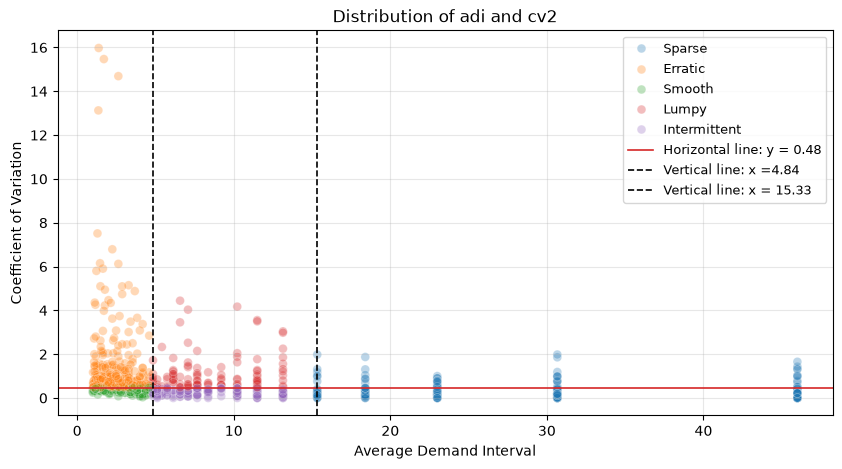

In [6]:
import seaborn as sns 

top_demand_profile_weekly = categorize_demand_profile(top_demand_profile_weekly)
plt.figure(figsize=(10, 5))
sns.scatterplot(x = "adi", y = "cv2", data = top_demand_profile_weekly, alpha = 0.3, s = 40, hue = "demand_category" )
cv2_q50 = top_demand_profile_weekly["cv2"].quantile(0.5)
adi_q50 = top_demand_profile_weekly["adi"].quantile(0.5)
adi_q75 = top_demand_profile_weekly["adi"].quantile(0.75)
plt.axhline(
    float(cv2_q50),
    color="C3",
    linestyle="-",
    linewidth=1.2,
    label=f"Horizontal line: y = {round(cv2_q50, 2)}",
)
plt.axvline(
    float(adi_q50),
    color="k",
    linestyle="--",
    linewidth=1.2,
    label=f"Vertical line: x ={round(adi_q50, 2)}",
)
plt.axvline(
    float(adi_q75),
    color="k",
    linestyle="--",
    linewidth=1.2,
    label=f"Vertical line: x = {round(adi_q75,2)}",
)
plt.legend(loc="upper right", fontsize=9)

plt.title("Distribution of adi and cv2")
plt.xlabel("Average Demand Interval")
plt.ylabel("Coefficient of Variation")
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
print(top_demand_profile_weekly["demand_category"].value_counts().to_string())


demand_category
Erratic         340
Sparse          264
Smooth          180
Intermittent    153
Lumpy           108


In [8]:
# Need lead time info to calculate the reorder point information
lead_time_info = pd.read_excel(r"C:\Users\Tzuying\OneDrive - smilesfirstcorp\Reporting & Business Intelligence\Purchasing\Updated_Priority_Products.xlsx",
              sheet_name="Sheet1")
top_demand_profile_weekly = (
    top_demand_profile_weekly
    .merge(lead_time_info[["item_id", "lead_time"]], how="left", left_on="item", right_on="item_id")
    .drop(columns="item_id")
)
top_demand_profile_weekly["lead_time_weeks"] = (
    pd.to_numeric(top_demand_profile_weekly["lead_time"], errors="coerce")
    .fillna(0)
    / 7
)

c:\Users\Tzuying\Project\BigQuery Pipeline\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [9]:
PROJECT_ID = "clean-pilot-456915-t0"
client = bigquery.Client(project= PROJECT_ID)
items = client.query("""  
                    Select *
                    From `clean-pilot-456915-t0.NetSuite.item`
                    """).to_dataframe()

top_demand_profile_weekly = (
    top_demand_profile_weekly
    .merge(items[["id", "cost","averagecost","lastpurchaseprice", "fullname"]], how="left", left_on="item", right_on="id")
    .drop(columns="id")
)

c:\Users\Tzuying\Project\BigQuery Pipeline\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\Tzuying\Project\BigQuery Pipeline\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [11]:
top_demand_profile_weekly.to_csv("top_demand_profile_weekly.csv", index=False)
%reset -f

# Calculate Reorder point

In [13]:
top_demand_profile_weekly = pd.read_csv("top_demand_profile_weekly.csv")
weekly_demand = pd.read_csv("weekly_demand.csv")

In [14]:
from scipy.stats import nbinom
import numpy as np

def croston_mean(item, demand, alpha=0.2, method="croston"):
    """
    Croston / SBA forecast of mean demand per period.
    demand : weekly_demand DataFrame with columns [item, trandate, weekly_demand]
    """
    series = (demand[demand["item"] == item]
              .sort_values("trandate")["weekly_demand"])   # ← weekly_demand col
    demand_arr = np.asarray(series, dtype=float)

    non_zero_idx = np.where(demand_arr > 0)[0]
    if len(non_zero_idx) == 0:
        return 0.0

    a = demand_arr[non_zero_idx[0]]
    p = float(non_zero_idx[0] + 1)           # ← typo fixed: non_zro_idx → non_zero_idx
    prev_idx = non_zero_idx[0]

    for idx in non_zero_idx[1:]:
        interval = idx - prev_idx
        a = alpha * demand_arr[idx] + (1 - alpha) * a
        p = alpha * interval        + (1 - alpha) * p
        prev_idx = idx

    return (1 - alpha / 2) * a / p if method == "sba" else a / p

# Bootstrap function — logic unchanged, now operates on weekly demand
def bootstrap_ss(demand_series, lead_review_periods, service_level, mu_LR, n_sim=1000):
    samples = [
        demand_series.sample(n=lead_review_periods, replace=True).sum()
        for _ in range(n_sim)
    ]
    ppf = np.percentile(samples, service_level * 100)
    return max(0, ppf - mu_LR)


# Alpha by demand_category
ALPHA_MAP = {
    "Smooth":            0.2,
    "Erratic":           0.2,
    "Intermittent":      0.1
}


top_demand_profile_weekly["sba_mean"] = top_demand_profile_weekly.apply(
    lambda row: croston_mean(
        row["item"],                                # ← item (not item_id)
        weekly_demand,                              # ← weekly_demand DataFrame (not top_all_item_bday)
        ALPHA_MAP.get(row["demand_category"], 0.2),     # ← demand_type (not demand_category)
        "sba"
    ),
    axis=1
)

review_cycle_weeks = 6  # 6 weeks
# Lead time + review cycle demand (all in weeks now)
top_demand_profile_weekly["leadTime_demand"]     = top_demand_profile_weekly["lead_time_weeks"] * top_demand_profile_weekly["sba_mean"]
top_demand_profile_weekly["review_cycle_demand"] = review_cycle_weeks * top_demand_profile_weekly["sba_mean"]
top_demand_profile_weekly["mu_LR"] = top_demand_profile_weekly["leadTime_demand"] + top_demand_profile_weekly["review_cycle_demand"]

# NB dispersion parameter k
top_demand_profile_weekly["k"] = np.where(
    top_demand_profile_weekly["std_weekly_demand"]**2 > top_demand_profile_weekly["avg_weekly_demand"],
    top_demand_profile_weekly["avg_weekly_demand"]**2 / (top_demand_profile_weekly["std_weekly_demand"]**2 - top_demand_profile_weekly["avg_weekly_demand"]),
    np.nan
)

# NB success parameter p
top_demand_profile_weekly["p_nb"] = top_demand_profile_weekly["k"] / (top_demand_profile_weekly["k"] + top_demand_profile_weekly["mu_LR"])

In [15]:
#bootstrap_ss(weekly_demand[weekly_demand["item"]==2138]["weekly_demand"], 7, service_level=0.7, mu_LR=28.028812718029357, n_sim=100)
#top_demand_profile_weekly[top_demand_profile_weekly["item"]==2138]

In [16]:


ss = pd.Series(np.nan, index=top_demand_profile_weekly.index)

# Smooth — bootstrap, service level 0.7
m1 = top_demand_profile_weekly["demand_category"] == "Smooth"
ss[m1] = top_demand_profile_weekly[m1].apply(
    lambda row: np.floor(bootstrap_ss(
        weekly_demand[weekly_demand["item"] == row["item"]]["weekly_demand"],
        int(round(row["lead_time_weeks"] + review_cycle_weeks)),   # must be int for .sample(n=)
        service_level=0.7,
        mu_LR=row["mu_LR"],
        n_sim=2000
    )), axis=1
)

# Intermittent — NB distribution
m2 = top_demand_profile_weekly["demand_category"] == "Intermittent"
ss[m2] = np.maximum(0,
    np.floor(nbinom.ppf(0.7, top_demand_profile_weekly.loc[m2, "k"], top_demand_profile_weekly.loc[m2, "p_nb"])
    - top_demand_profile_weekly.loc[m2, "mu_LR"])
)

# Erratic — bootstrap, service level 0.8
m3 = top_demand_profile_weekly["demand_category"] == "Erratic"
ss[m3] = top_demand_profile_weekly[m3].apply(
    lambda row: np.floor(bootstrap_ss(
                                        weekly_demand[weekly_demand["item"] == row["item"]]["weekly_demand"],
                                        int(round(row["lead_time_weeks"] + review_cycle_weeks)),
                                        service_level=0.8,
                                        mu_LR=row["mu_LR"],
                                        n_sim=2000)), axis=1)

# Lumpy — demand probability forecast, SS = 20% of LT demand
m4 = top_demand_profile_weekly["demand_category"] == "Lumpy"
top_demand_profile_weekly.loc[m4, "demand_probability"] = 1 / top_demand_profile_weekly.loc[m4, "adi"]

lt_m4 = (
    top_demand_profile_weekly.loc[m4, "lead_time_weeks"]
    * top_demand_profile_weekly.loc[m4, "demand_probability"]
    * top_demand_profile_weekly.loc[m4, "avg_weekly_demand"]    # ← mean_non_zero → avg_weekly_demand
)
rc_m4 = (
    review_cycle_weeks
    * top_demand_profile_weekly.loc[m4, "demand_probability"]
    * top_demand_profile_weekly.loc[m4, "avg_weekly_demand"]
)
top_demand_profile_weekly.loc[m4, "leadTime_demand"]     = lt_m4
top_demand_profile_weekly.loc[m4, "review_cycle_demand"] = rc_m4
ss[m4] = np.floor(lt_m4 * 0.2)

# Sparse
m5 = top_demand_profile_weekly["demand_category"] == "Sparse"
ss[m5] = 0

top_demand_profile_weekly["SS"] = ss.clip(lower=0).fillna(0)

top_demand_profile_weekly["ROP"] = pd.Series(
    np.ceil(top_demand_profile_weekly["leadTime_demand"] + top_demand_profile_weekly["SS"]),
    index=top_demand_profile_weekly.index,
).fillna(0)

top_demand_profile_weekly["psl"] = pd.Series(
    np.ceil(top_demand_profile_weekly["review_cycle_demand"] + top_demand_profile_weekly["ROP"]),
    index=top_demand_profile_weekly.index,
).fillna(0)


top_demand_profile_weekly.loc[m5, ["ROP", "psl"]] = 0

In [17]:
top_demand_profile_weekly.to_csv("top_demand_profile_weekly.csv")

In [18]:
top_demand_profile_weekly

,item,avg_weekly_demand,std_weekly_demand,median_weekly_demand,max_weekly_demand,sales_weeks,zero_weeks,adi,cv2,demand_category,...,sba_mean,leadTime_demand,review_cycle_demand,mu_LR,k,p_nb,demand_probability,SS,ROP,psl
0,949,2.750000,1.500000,3.0,4.0,4,88,23.000000,0.297521,Sparse,...,0.112883,0.000000,0.677297,0.677297,NaN,NaN,NaN,0.0,0.0,0.0
1,2093,4.588235,3.365570,4.0,17.0,51,41,1.803922,0.538054,Erratic,...,3.918131,3.358398,23.508788,26.867186,3.123973,0.104163,NaN,0.0,4.0,28.0
2,2113,27.647059,15.495615,24.0,72.0,34,58,2.705882,0.314137,Smooth,...,7.000277,3.000119,42.001660,45.001779,3.597546,0.074025,NaN,31.0,35.0,78.0
3,2129,4.192308,4.252051,3.0,21.0,52,40,1.769231,1.028705,Erratic,...,2.767529,2.767529,16.605174,19.372702,1.265546,0.061320,NaN,4.0,7.0,24.0
4,2138,9.390244,8.233705,8.0,47.0,41,51,2.243902,0.768842,Erratic,...,4.004116,4.004116,24.024697,28.028813,1.509780,0.051112,NaN,14.0,19.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,72588,6.000000,NaN,6.0,6.0,1,91,92.000000,NaN,Sparse,...,0.067500,0.000000,0.405000,0.405000,NaN,NaN,NaN,0.0,0.0,0.0
1041,73039,2.000000,NaN,2.0,2.0,1,91,92.000000,NaN,Sparse,...,0.022500,0.000000,0.135000,0.135000,NaN,NaN,NaN,0.0,0.0,0.0
1042,73678,5.000000,NaN,5.0,5.0,1,91,92.000000,NaN,Sparse,...,0.054878,0.000000,0.329268,0.329268,NaN,NaN,NaN,0.0,0.0,0.0
1043,73835,1.000000,NaN,1.0,1.0,1,91,92.000000,NaN,Sparse,...,0.010714,0.000000,0.064286,0.064286,NaN,NaN,NaN,0.0,0.0,0.0
